In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime


In [2]:
sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))

from src.quantum_hrp import average_density_matrix, compute_distance_matrix
from src.hrp_ordering import hrp_order_from_distance, hrp_order_from_correlation
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

In [3]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

In [4]:
print("returns:", returns.shape, returns.index.min(), returns.index.max())
print("features:", features.shape)
print("features.npy mtime:", datetime.datetime.fromtimestamp(os.path.getmtime("../../data/features.npy")))

returns: (616, 169) 2021-11-11 00:00:00 2024-12-31 00:00:00
features: (169, 616, 6)
features.npy mtime: 2025-12-31 01:27:33.607783


In [5]:
# Use the same horizon for returns and features
T_common = min(len(returns), features.shape[1])

returns_cut = returns.iloc[-T_common:]
corr = returns_cut.corr()

features_cut = features[:, -T_common:, :]

print("T_common:", T_common)
print("returns_cut:", returns_cut.shape, returns_cut.index.min(), returns_cut.index.max())
print("features_cut:", features_cut.shape)

T_common: 616
returns_cut: (616, 169) 2021-11-11 00:00:00 2024-12-31 00:00:00
features_cut: (169, 616, 6)


In [6]:
# Classical HRP
order_classical = hrp_order_from_correlation(corr)
corr_classical = corr.iloc[order_classical, :].iloc[:, order_classical]

# Quantum HRP
alpha = 2.0
N = features_cut.shape[0]
rhos = []

for i in range(N):
    rho = average_density_matrix(features_cut[i], alpha=alpha)
    rhos.append(rho)

D_quantum = compute_distance_matrix(rhos)
order_quantum = hrp_order_from_distance(D_quantum)
corr_quantum = corr.iloc[order_quantum, :].iloc[:, order_quantum]

# Diagnostics (NOW order_quantum exists)
tickers = corr.columns.to_list()
print("Same positions (%):", 100 * np.mean(order_classical == order_quantum))
print("Classical first 20:", [tickers[i] for i in order_classical[:20]])
print("Quantum first 20:", [tickers[i] for i in order_quantum[:20]])
print("Mean abs diff (ordered corr):",
      np.mean(np.abs(corr_classical.values - corr_quantum.values)))

Same positions (%): 1.183431952662722
Classical first 20: ['KRBN', 'VZ', 'T', 'SOYB', 'CORN', 'WEAT', 'TMUS', 'BMY', 'MRNA', 'WBD', 'TGT', 'XRP-USD', 'DOGE-USD', 'BNB-USD', 'SOL-USD', 'AVAX-USD', 'BTC-USD', 'ETH-USD', 'ADA-USD', 'DOT-USD']
Quantum first 20: ['OXY', 'NFLX', 'REGN', 'KRBN', 'CORN', 'TGT', 'WMT', 'WEAT', 'BYDDF', 'XRP-USD', 'TCEHY', 'SOL-USD', 'NKE', 'GILD', 'BABA', 'SCHW', 'BNB-USD', 'IGOV', 'INTC', 'PANW']
Mean abs diff (ordered corr): 0.19661044500735755


Returns shape: (616, 169)
Features shape: (169, 616, 6)
Correlation shape: (169, 169)


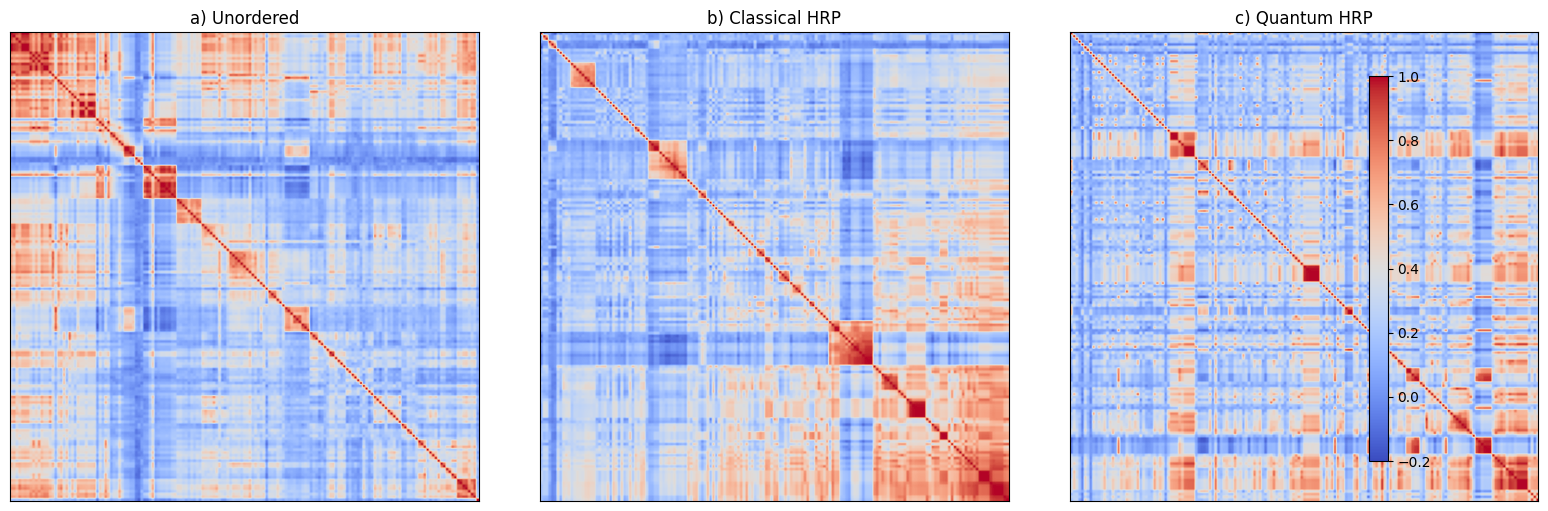

Classical first 20: ['KRBN', 'VZ', 'T', 'SOYB', 'CORN', 'WEAT', 'TMUS', 'BMY', 'MRNA', 'WBD', 'TGT', 'XRP-USD', 'DOGE-USD', 'BNB-USD', 'SOL-USD', 'AVAX-USD', 'BTC-USD', 'ETH-USD', 'ADA-USD', 'DOT-USD']
Quantum first 20: ['OXY', 'NFLX', 'REGN', 'KRBN', 'CORN', 'TGT', 'WMT', 'WEAT', 'BYDDF', 'XRP-USD', 'TCEHY', 'SOL-USD', 'NKE', 'GILD', 'BABA', 'SCHW', 'BNB-USD', 'IGOV', 'INTC', 'PANW']


In [7]:
# CELL: Figure 3 Correlation Matrices
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Validaciones previas
print(f"Returns shape: {returns_cut.shape}")
print(f"Features shape: {features_cut.shape}")
print(f"Correlation shape: {corr.shape}")

# a) Unordered Correlation
im0 = axs[0].imshow(corr, cmap='coolwarm', vmin=-0.2, vmax=1)
axs[0].set_title('a) Unordered', fontsize=12)
axs[0].set_xticks([])
axs[0].set_yticks([])

# b) Classical HRP - Correlation Reordered
order_classical = hrp_order_from_correlation(corr)
corr_classical = corr.iloc[order_classical, :].iloc[:, order_classical]
im1 = axs[1].imshow(corr_classical, cmap='coolwarm', vmin=-0.2, vmax=1)
axs[1].set_title('b) Classical HRP', fontsize=12)
axs[1].set_xticks([])
axs[1].set_yticks([])

# c) Quantum HRP - Correlation Reordered  
order_quantum = hrp_order_from_distance(D_quantum)
corr_quantum = corr.iloc[order_quantum, :].iloc[:, order_quantum]
im2 = axs[2].imshow(corr_quantum, cmap='coolwarm', vmin=-0.2, vmax=1)
axs[2].set_title('c) Quantum HRP', fontsize=12)
axs[2].set_xticks([])
axs[2].set_yticks([])

# Colorbar compartido
fig.colorbar(im0, ax=axs, fraction=0.02, pad=0.04)

plt.tight_layout()
plt.savefig('figures/figure3_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Classical first 20: {corr.columns[order_classical[:20]].tolist()}")
print(f"Quantum first 20: {corr.columns[order_quantum[:20]].tolist()}")


In [9]:
# Aseguramos simetría y ceros en diagonal (por errores de flotante)
D_quantum = (D_quantum + D_quantum.T) / 2
np.fill_diagonal(D_quantum, 0)

# Verificación rápida: Si todos los valores son muy cercanos (ej. 0.0001), 
# el gráfico se verá gris. Normaliza si es necesario para visualizar, 
# aunque para el cálculo real usa los valores crudos.
print(f"Max dist: {D_quantum.max()}, Min dist: {D_quantum.min()}")

Max dist: 0.36990588523398427, Min dist: 0.0


In [10]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# 1. Convertimos la matriz cuadrada a formato condensado para linkage
# (scipy asume que la diagonal es 0 y es simétrica)
condensed_dist = squareform(D_quantum, checks=False)

# 2. Hacemos el clustering jerárquico (Single o Ward suelen funcionar bien aquí)
# El paper de HRP original usa 'single', pero a veces 'ward' visualiza mejor los bloques.
link = linkage(condensed_dist, method='single') 

# 3. Obtenemos el orden de las hojas (los índices ordenados)
order_quantum_array = leaves_list(link)

# 4. Reordenamos la matriz
Dqord = D_quantum[np.ix_(order_quantum_array, order_quantum_array)]

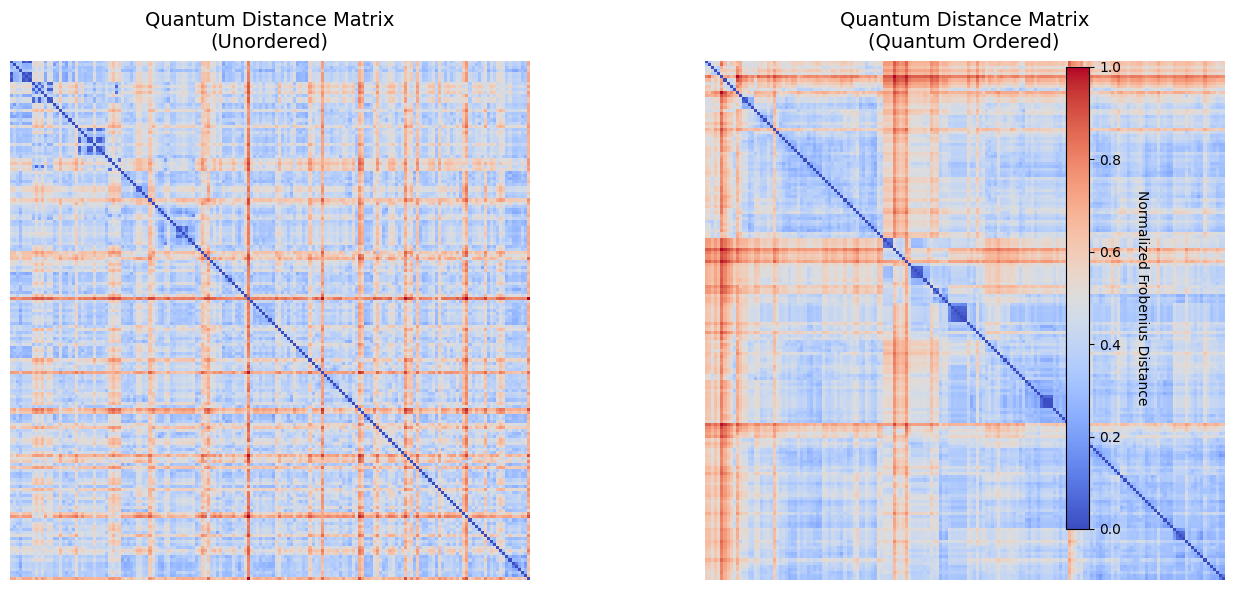

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# --- 1. PREPROCESAMIENTO ROBUSTO ---
# Aseguramos que la matriz sea perfectamente simétrica y con diagonal 0
D_clean = (D_quantum + D_quantum.T) / 2
np.fill_diagonal(D_clean, 0)

# TRUCO VISUAL: Normalizar la matriz para que el plot se vea contrastado
# (Esto es solo para visualizar, no para los cálculos financieros)
D_min, D_max = D_clean.min(), D_clean.max()
D_normalized = (D_clean - D_min) / (D_max - D_min)

# --- 2. CLUSTERING PARA VISUALIZACIÓN ---
# Convertimos a formato condensado
condensed_dist = squareform(D_clean, checks=False)

# CLAVE: Usamos 'ward' en lugar de 'single'. 
# 'Single' produce el efecto escalera (chaining). 'Ward' produce bloques (clusters).
# El paper probablemente usó Ward o Average para lograr esa figura tan nítida.
link_q = linkage(condensed_dist, method='ward') 

# Obtenemos el orden
order_q = leaves_list(link_q)

# Reordenamos la matriz normalizada
D_q_ordered = D_normalized[np.ix_(order_q, order_q)]
D_q_unordered = D_normalized

# --- 3. PLOTTING EXACTO ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Mapa de color: 'jet', 'turbo' o 'coolwarm' suelen dar ese look científico
cmap = 'coolwarm' 

# a) Unordered
im0 = axs[0].imshow(D_q_unordered, cmap=cmap, aspect='equal', interpolation='nearest')
axs[0].set_title('Quantum Distance Matrix\n(Unordered)', fontsize=14, pad=10)
axs[0].axis('off') # Quitamos los ejes para que se vea limpio como en el paper

# b) Ordered (Quantum Ordering)
im1 = axs[1].imshow(D_q_ordered, cmap=cmap, aspect='equal', interpolation='nearest')
axs[1].set_title('Quantum Distance Matrix\n(Quantum Ordered)', fontsize=14, pad=10)
axs[1].axis('off')

# Barra de color ajustada
cbar = fig.colorbar(im1, ax=axs, fraction=0.03, pad=0.03)
cbar.set_label('Normalized Frobenius Distance', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()